In [6]:
pip install pandas numpy matplotlib scikit_learn

Note: you may need to restart the kernel to use updated packages.


First 5 Records
  User_ID            Product     Category  Rating
0      U1     Wireless Mouse  Electronics       5
1      U1         Laptop Bag  Accessories       4
2      U1          USB Cable  Electronics       4
3      U2        Smart Watch  Electronics       5
4      U2  Bluetooth Speaker  Electronics       4

Dataset Shape:
(21, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   User_ID   21 non-null     object
 1   Product   21 non-null     object
 2   Category  21 non-null     object
 3   Rating    21 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 804.0+ bytes
None

Missing Values:
User_ID     0
Product     0
Category    0
Rating      0
dtype: int64

Statistical Summary:
          Rating
count  21.000000
mean    4.428571
std     0.597614
min     3.000000
25%     4.000000
50%     4.000000
75%     5.000000
max 

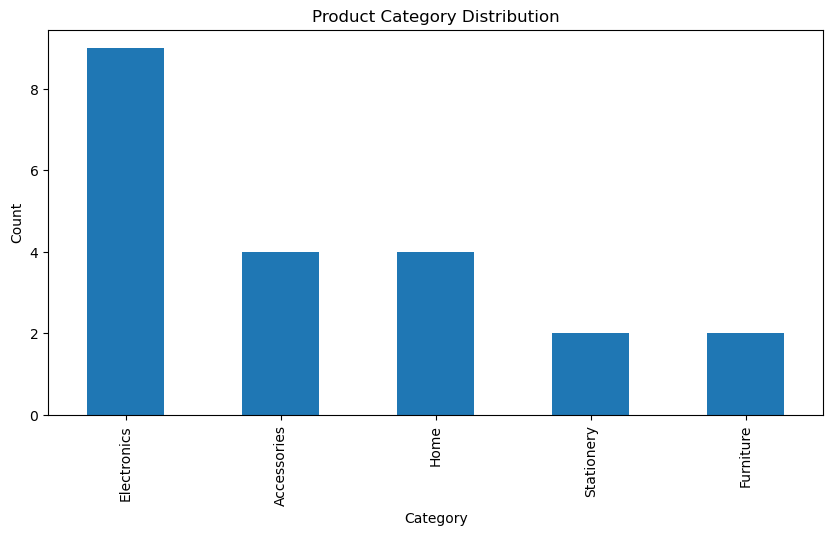


Encoded Dataset
   User_ID  Product  Category  Rating
0        0       20         1       5
1        0        6         0       4
2        0       17         1       4
3        1       14         1       5
4        1        1         1       4

Recommendation Model Trained Successfully

Available User IDs
[0 1 2 3 4 5 6]

Available Categories
[1 0 3 4 2]



Enter User ID :  0
Enter Category Number :  1
Enter Rating (1 to 5) :  4


C:\Users\Hemanjana\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\Hemanjana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Recommended Products
Product : USB Cable
Category : Electronics
Rating : 4

Product : Wireless Mouse
Category : Electronics
Rating : 5

Product : Laptop Bag
Category : Accessories
Rating : 4

Final Recommendation List
['USB Cable', 'Wireless Mouse', 'Laptop Bag']

Accuracy Score
1.0

Confusion Matrix
[[5]]


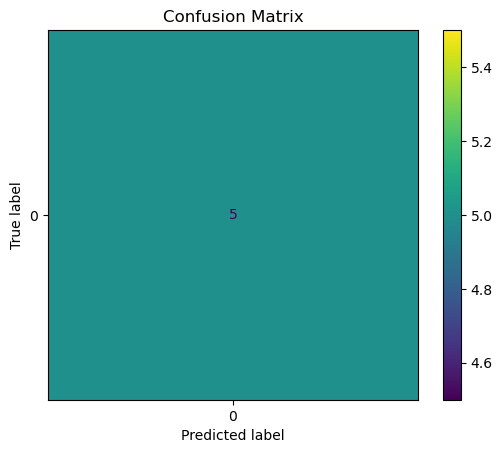

C:\Users\Hemanjana\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


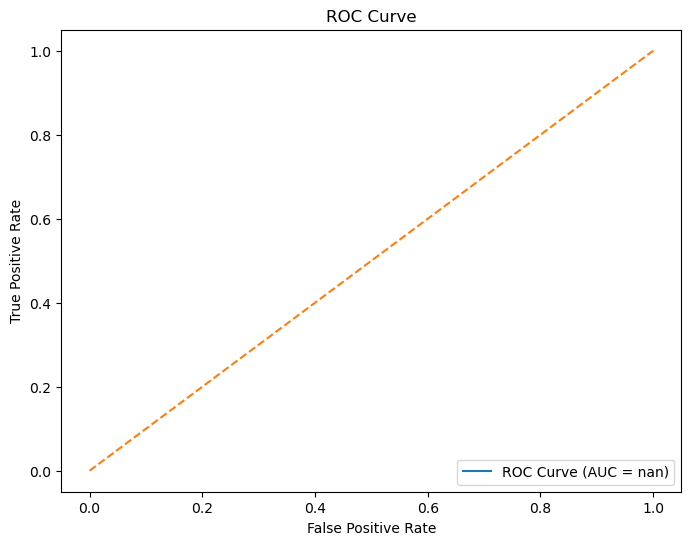


AUC Score
nan

Project Executed Successfully


In [7]:
# E-COMMERCE PRODUCT RECOMMENDATION SYSTEM USING MACHINE LEARNING

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score

# Load Dataset
df = pd.read_csv("ecommerce_data.csv")

# Display First Five Records
print("First 5 Records")
print(df.head())

# Display Dataset Shape
print("\nDataset Shape:")
print(df.shape)

# Display Dataset Information
print("\nDataset Information:")
print(df.info())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove Duplicate Records
df.drop_duplicates(inplace=True)

# Display Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Count Products
print("\nProduct Count:")
product_count = df['Product'].value_counts()
print(product_count)

# Count Categories
print("\nCategory Count:")
category_count = df['Category'].value_counts()
print(category_count)

# Visualize Product Categories
plt.figure(figsize=(10, 5))
category_count.plot(kind='bar')
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Label Encoding
user_encoder = LabelEncoder()
product_encoder = LabelEncoder()
category_encoder = LabelEncoder()

df['User_ID'] = user_encoder.fit_transform(df['User_ID'])
df['Product'] = product_encoder.fit_transform(df['Product'])
df['Category'] = category_encoder.fit_transform(df['Category'])

# Display Encoded Dataset
print("\nEncoded Dataset")
print(df.head())

# Build Recommendation Model
X_recommend = df[['User_ID', 'Category', 'Rating']]

recommendation_model = NearestNeighbors(
    n_neighbors=3,
    metric='euclidean'
)

recommendation_model.fit(X_recommend)

print("\nRecommendation Model Trained Successfully")

# Display Available User IDs
print("\nAvailable User IDs")
print(df['User_ID'].unique())

# Display Available Categories
print("\nAvailable Categories")
print(df['Category'].unique())

# User Input
user_id = int(input("\nEnter User ID : "))
category = int(input("Enter Category Number : "))
rating = int(input("Enter Rating (1 to 5) : "))

# Generate Recommendations
distance, index = recommendation_model.kneighbors(
    [[user_id, category, rating]]
)

# Display Recommended Products
print("\nRecommended Products")

recommended_products = []

for i in index[0]:

    product_name = product_encoder.inverse_transform(
        [df.iloc[i]['Product']]
    )[0]

    category_name = category_encoder.inverse_transform(
        [df.iloc[i]['Category']]
    )[0]

    product_rating = df.iloc[i]['Rating']

    recommended_products.append(product_name)

    print("Product :", product_name)
    print("Category :", category_name)
    print("Rating :", product_rating)
    print()

# Display Final Recommendations
print("Final Recommendation List")
print(recommended_products)

# Classification for Evaluation Metrics
X = df[['User_ID', 'Category']]
y = (df['Rating'] >= 4).astype(int)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train Logistic Regression Model
classification_model = LogisticRegression()

classification_model.fit(X_train, y_train)

# Predictions
y_pred = classification_model.predict(X_test)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score")
print(accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_prob = classification_model.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label="ROC Curve (AUC = %0.2f)" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("\nAUC Score")
print(roc_auc)

print("\nProject Executed Successfully")